In [2]:
import requests
from bs4 import BeautifulSoup

In [9]:
url = "https://finance.yahoo.com/markets/"
response = requests.get(url, headers=headers)

In [10]:
soup = BeautifulSoup(response.text, "html.parser")
headers = {"User-Agent": "Mozilla/5.0"}

In [12]:
print(soup.title.text)

Markets: World Indexes, Futures, Bonds, Currencies, Stocks & ETFs - Yahoo Finance


In [13]:
rows = soup.find_all("tr")
for row in rows[:10]:
    print(row.get_text(separator=" | ", strip=True))

Symbol | Price | Change %
VIX | 15.30 | +0.77 | (+5.30%) | +5.30%
Russell 2000 | 2,975.65 | +7.38 | (+0.25%) | +0.25%
IBOVESPA | 185,147.16 | -40.84 | (-0.02%) | -0.02%
Nasdaq | 26,506.99 | -77.11 | (-0.29%) | -0.29%
S&P/TSX Composite index | 36,513.80 | -119.30 | (-0.33%) | -0.33%
US Dollar Index | 98.82 | -0.35 | (-0.35%) | -0.35%
S&P 500 | 7,718.60 | -29.11 | (-0.38%) | -0.38%
Dow 30 | 53,414.25 | -271.85 | (-0.51%) | -0.51%
Symbol | Price | Change %


In [16]:
tables = soup.find_all("table")
print({len(tables)})

{21}


In [17]:
for i, table in enumerate(tables):
    preview = table.get_text(separator=" | ", strip=True)[:150]
    print(f"Table {i}: {preview}")

Table 0: Symbol | Price | Change % | VIX | 15.30 | +0.77 | (+5.30%) | +5.30% | Russell 2000 | 2,975.65 | +7.38 | (+0.25%) | +0.25% | IBOVESPA | 185,147.16 | -4
Table 1: Symbol | Price | Change % | Euronext 100 Index | 1,917.04 | +6.51 | (+0.34%) | +0.34% | CAC 40 | 8,306.15 | +27.38 | (+0.33%) | +0.33% | EURO STOXX 50
Table 2: Symbol | Price | Change % | KOSPI Composite Index | 7,161.17 | +165.78 | (+2.37%) | +2.37% | SSE Composite Index | 3,946.99 | +14.29 | (+0.36%) | +0.3
Table 3: Symbol | Price | Change % | Copper Dec 26 | 6.80 | +0.12 | (+1.80%) | +1.80% | Crude Oil | 92.96 | +1.48 | (+1.62%) | +1.62% | Brent Crude Oil Last Da
Table 4: Symbol | Price | Change % | USD/MXN | 16.9490 | +0.0450 | (+0.27%) | +0.27% | USD/AUD | 1.3857 | +0.0006 | (+0.04%) | +0.04% | USD/GBP | 0.7387 | +0.0
Table 5: Symbol | Price | Change % | iShares 20+ Year Treasury Bond ETF | 82.21 | +0.14 | (+0.17%) | +0.17% | 10 Yr T-Note Futures | 107.50 | +0.03 | (+0.03%) 
Table 6: Sector | Market Weight | YTD Re

In [18]:
my_table = tables[3]

In [19]:
rows = my_table.find_all("tr")

data = []
for row in rows:
    cells = row.find_all(["td", "th"])
    cell_text = [c.get_text(strip=True) for c in cells]
    if cell_text:
        data.append(cell_text)

header = data[0]
clean_rows = data[1:]

print(header)
for r in clean_rows:
    print(r)

['Symbol', '', 'Price', 'Change %']
['Copper Dec 26', '', '6.80+0.12(+1.80%)', '+1.80%']
['Crude Oil', '', '92.96+1.48(+1.62%)', '+1.62%']
['Brent Crude Oil Last Day Financ', '', '97.59+1.31(+1.36%)', '+1.36%']
['Silver', '', '67.64+0.89(+1.33%)', '+1.33%']
['Platinum Oct 26', '', '1,844.00+18.00(+0.99%)', '+0.99%']
['Gold', '', '4,478.90+2.30(+0.05%)', '+0.05%']
['Natural Gas Oct 26', '', '2.9500-0.0250(-0.84%)', '-0.84%']


In [20]:
import re

In [22]:
import re

clean_data = []
for r in clean_rows:
    name = r[0]
    raw = r[2]        # e.g. '6.80+0.12(+1.80%)'
    pct = r[3]         # e.g. '+1.80%'  <- already clean, just reuse it

    match = re.match(r"([\d,]+\.?\d*)([+-][\d,]+\.?\d*)", raw)
    if match:
        price, change = match.groups()
        clean_data.append([name, price, change, pct])

print(clean_data)

[['Copper Dec 26', '6.80', '+0.12', '+1.80%'], ['Crude Oil', '92.96', '+1.48', '+1.62%'], ['Brent Crude Oil Last Day Financ', '97.59', '+1.31', '+1.36%'], ['Silver', '67.64', '+0.89', '+1.33%'], ['Platinum Oct 26', '1,844.00', '+18.00', '+0.99%'], ['Gold', '4,478.90', '+2.30', '+0.05%'], ['Natural Gas Oct 26', '2.9500', '-0.0250', '-0.84%']]


In [28]:
import pandas as pd

df = pd.DataFrame(clean_data, columns=["Name", "Price", "Change", "Change %"])

df["Price"] = df["Price"].str.replace(",", "").astype(float)
df["Change %"] = df["Change %"].str.replace("%", "").astype(float)

print(df)

                              Name    Price   Change  Change %
0                    Copper Dec 26     6.80    +0.12      1.80
1                        Crude Oil    92.96    +1.48      1.62
2  Brent Crude Oil Last Day Financ    97.59    +1.31      1.36
3                           Silver    67.64    +0.89      1.33
4                  Platinum Oct 26  1844.00   +18.00      0.99
5                             Gold  4478.90    +2.30      0.05
6               Natural Gas Oct 26     2.95  -0.0250     -0.84


In [30]:
import matplotlib.pyplot as plt

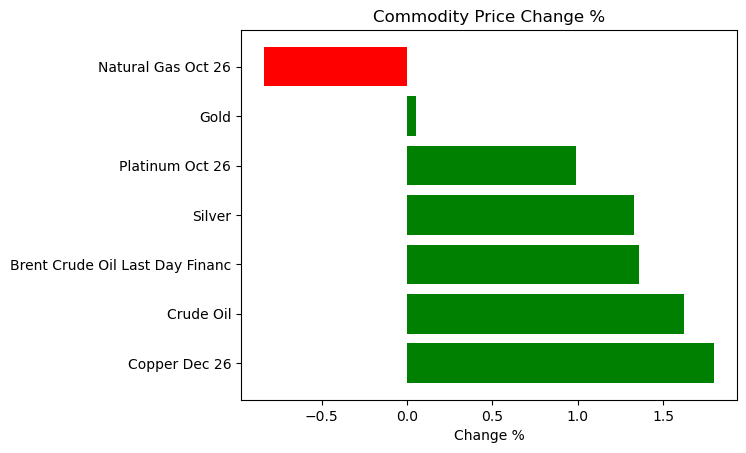

In [35]:
colors = ["green" if x > 0 else "red" for x in df["Change %"]]
plt.barh(df["Name"], df["Change %"], color=colors)
plt.xlabel("Change %")
plt.title("Commodity Price Change %")
plt.show()

In [36]:
df.to_csv("commodities.csv", index=False)